# Анализ лояльности пользователей Яндекс Афиши`

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---
---

**Задача 1.1:** Выгрузка в датафрейм информации из базы данных Яндекс Афиши(`data-analyst-afisha`), используя SQL-запрос



Сделаем импорт библиотек

In [1]:
!pip install pandas sqlalchemy python-dotenv matplotlib seaborn phik

import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os 

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Для подключения к БД используем параметры предложенные в задании. Параметры для подключеня сохранены в файл `.env` файл в целях безопасности

In [2]:
# укажем путь к файлу .env
path_env = r"C:\Users\VladimirVWV\jupyter\анализ лоялиьности афиши\.env"

try:
    # загрузим данные файла
    load_dotenv(path_env)
except:
    load_dotenv()

Запишем параметры для подключения в переменные и создадим строку для подключения к БД

In [3]:
# записываем параметы для подключения в переменные
user = os.getenv('DB_USER')
pwd = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
db = os.getenv('DB_NAME')

# создаём строку для подключения к БД
connection_string = f'postgresql://{user}:{pwd}@{host}:{port}/{db}'

Запишем в переменную запрос для выгрузки данных из БД

In [4]:
# записываем sql запрос в переменную для дальнейшей выгрузки данных
sql_query = '''
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)
SELECT 
    p.user_id
  , p.device_type_canonical
  , p.order_id
  , p.created_dt_msk as order_dt
  , p.created_ts_msk as order_ts
  , p.currency_code
  , p.revenue
  , p.tickets_count
  , EXTRACT(DAY FROM (p.created_dt_msk - lag(p.created_dt_msk, 1, NULL) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk))) AS days_since_prev
  , p.event_id  
  , p.service_name  
  , e.event_type_main
  , r.region_name 
  , c.city_name 
FROM afisha.purchases p
JOIN afisha.events e ON p.event_id = e.event_id 
JOIN afisha.city c ON e.city_id = c.city_id 
JOIN afisha.regions r ON c.region_id  = r.region_id  
WHERE 1=1
AND p.device_type_canonical IN('desktop', 'mobile')
AND e.event_type_main != 'фильм'
ORDER BY p.user_id
'''

Создадим подключение к БД используя `connection_string` и запишем в датафрейм

In [5]:
# создаём подключение к БД
engine = create_engine(connection_string)

# записываем данные по запросу в датафрейм
df = pd.read_sql_query(sql_query, con=engine)

Выполним настройки вывода датафрейма для удобства

In [6]:
# отображение всех столбцов
pd.set_option('display.max_columns', None)


Полученная выгрузка из базы данных SQL, записанная в `df` содержит следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (в БД -  `created_dt_msk`);
- `order_ts` — дата и время создания заказа (в БД - `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---

**Задача 1.2:** Изучиение общей информации о выгруженных данных и оценка корректности выгрузки, объёма полученных данных.

Изучим информацию о датасете, типы данных, наличие пропусков, объём данных

In [7]:
# выводим информацию о датасете
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  service_name           290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  region_name            290611 non-null  str           


Полученная выгрузка состоит из 290611 строк, содержит 14 столбцов. Столбцы имеют следующие типы данных:
- datetime64 - 2 столбца с точностью до микросекунд
- float64 - 2 столбца
- int64 - 3 столбца
- object - 7 столбцов

По полученным данных в датасете только одна колонака имеет пропупуски - `ays_since_prev`
Выведем часть загруженных данных для ознакомления с корректностью определённых типов данных в датасете

In [8]:
# вывод первых 10 строк датасета
print(df.head())

           user_id device_type_canonical  order_id   order_dt  \
0  0002849b70a3ce2                mobile   4359165 2024-08-20   
1  0005ca5e93f2cf4                mobile   7965605 2024-07-23   
2  0005ca5e93f2cf4                mobile   7292370 2024-10-06   
3  000898990054619                mobile   1139875 2024-07-13   
4  000898990054619                mobile    972400 2024-10-04   

             order_ts currency_code  revenue  tickets_count  days_since_prev  \
0 2024-08-20 16:08:03           rub  1521.94              4              NaN   
1 2024-07-23 18:36:24           rub   289.45              2              NaN   
2 2024-10-06 13:56:02           rub  1258.57              4             75.0   
3 2024-07-13 19:40:48           rub     8.49              2              NaN   
4 2024-10-04 22:33:15           rub  1390.41              3             83.0   

   event_id        service_name event_type_main           region_name  \
0    169230        Край билетов           театр    Каме

В целом типы данных определенных корректно, но колонку `days_since_prev` нужно преобразовать к целому типу данных, столбец показывает целое количество дней между текущей покупокой и прошлой. Такде имеет смысл понизить размерность некоторых колонок, таких как:
- `order_id`
- `tickets_count`
- `days_since_prev`

Таким образом загруженный датасет на первый взгляд имеет данных хорошего качества, почти нет пропусков, типы данных почти во всех столбцах определены корректно

---
---

###  2. Предобработка данных


**Задача 2.1:** Приведём выручку к единой валюте — российскому рублю.

Загрузим информацию о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv` в датасет `final_tickets_tenge_df`. Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

In [9]:
# запишем путь к файлу с информацией о курсе в переменную path_final_tickets_tenge
path_final_tickets_tenge = 'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'

# загрузим данные о курсе в датасет final_tickets_tenge_df
final_tickets_tenge_df = pd.read_csv(path_final_tickets_tenge)

# выведем несколько значений полученного датасета с курсом валют
final_tickets_tenge_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [10]:
# выведем типы колонок в полученном датасете валют
final_tickets_tenge_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB


Видими, что в `final_tickets_tenge_df` дата курса выражена типом данных `object`, преобразуем в тип дат

In [11]:
final_tickets_tenge_df['data'] = pd.to_datetime(final_tickets_tenge_df['data'])

Приведём данные по выручке в основном датасете к одной валюте - рублям

In [12]:
# создадим функцию для преобразования тенге в рубли, используя выгрузку в final_tickets_tenge_df
def kzt_in_rub(row):
    # запишем в временные переменныые
    currency_code = row['currency_code']
    revenue = row['revenue']
    order_dt = row['order_dt']

    # проверка, нужно ли переводить в рубли
    if currency_code == 'kzt':
        # если в тенге
        # получим курс на дату заказа
        curs_row = final_tickets_tenge_df[final_tickets_tenge_df['data'] == order_dt]

         # Если курс найден
        if len(curs_row) > 0: 
            curs = curs_row['curs'].iloc[0]

            # возвращаем преобразованные значения серией
            return round(revenue * curs / 100, 2)
        else:
            # курс не найден
            return None        
    else:
        # если уже рубли
        return revenue

# создадим столбец revenue_rub, в котором вся выручка в рублях
df['revenue_rub'] = df.apply(kzt_in_rub, axis=1)

Проверим, во всех ли заказах теперь валюта рубли

In [13]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк,1390.41


Видим, что действительно добавление столбца `revenue_rub` прошло успешно и теперь у нас есть столбец показывающий всю выручку в рублях

---

**Задача 2.2:** Проверка на пропуски, преобразование типов данных, обработка возможных ошибок в данных


Выполним проверку на пропуски основного датасета `df`

In [14]:
pd.DataFrame({
    'cnt_null': df.isna().sum(),
    'percent_null': (100 * df.isna().sum()/len(df)).round(2)
})

,cnt_null,percent_null
user_id,0,0.00
device_type_canonical,0,0.00
order_id,0,0.00
order_dt,0,0.00
order_ts,0,0.00
currency_code,0,0.00
revenue,0,0.00
tickets_count,0,0.00
days_since_prev,21933,7.55
event_id,0,0.00


По полученным данным видим, что пропуски действительно имеются только в столбце `days_since_prev` в количестве 21933, что составляет 7,55%. Данные пропуски обусловлены тем, что некоторые пользователи совершили только 1 заказ и предыдущего заказа у них нет

Понизим размерность колонок `order_id`, `tickets_count`, `event_id`, `days_since_prev`

In [15]:
# выведем исходные типы данных до преобразований
df[['order_id', 'tickets_count', 'event_id', 'days_since_prev']].info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         290611 non-null  int64  
 1   tickets_count    290611 non-null  int64  
 2   event_id         290611 non-null  int64  
 3   days_since_prev  268678 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 8.9 MB


In [16]:
# понижение типа столбца order_id
df['order_id'] = pd.to_numeric(df['order_id'], downcast='integer')

# понижение типа столбца tickets_count
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')

# понижение типа столбца event_id
df['event_id'] = pd.to_numeric(df['event_id'], downcast='integer')

# перед понижением размерность столбца days_since_prev нужно перевести его в целочисленный тип
df['days_since_prev'] = df['days_since_prev'].astype('Int64')

# понижение типа столбца days_since_prev
df['days_since_prev'] = pd.to_numeric(df['days_since_prev'], downcast='integer')

# повторный вывод типов данных столбцов после преобразования, для видимости результата преобразований
df[['order_id', 'tickets_count', 'event_id', 'days_since_prev']].info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   order_id         290611 non-null  int32
 1   tickets_count    290611 non-null  int8 
 2   event_id         290611 non-null  int32
 3   days_since_prev  268678 non-null  Int16
dtypes: Int16(1), int32(2), int8(1)
memory usage: 3.3 MB


Колонки с датами имеют точность до микросекунд, в конктесте задачи, такая точность - излишняя, в поле `order_dt` оставим только даты, а точность `order_ts` изменим до секунд

In [17]:
# оставляем только дату в order_dt
df['order_dt'] = pd.to_datetime(df['order_dt'].dt.date)

# уменьшаем точность поля order_ts до секунд
df['order_ts'] = df['order_ts'].astype('datetime64[s]')

# выведем новые типы данных преобразованных колонок с датами
df[['order_dt', 'order_ts']].info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype        
---  ------    --------------   -----        
 0   order_dt  290611 non-null  datetime64[s]
 1   order_ts  290611 non-null  datetime64[s]
dtypes: datetime64[s](2)
memory usage: 4.4 MB


Проверим, если в ключевых столбцах категории с номинальными данными

In [18]:
# проверим есть ли номинальные значения в столбце event_type_main
df['event_type_main'].value_counts()

event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: count, dtype: int64

В поле event_type_main видим что есть категория другое, она может обозначать как пропуски, но более вероятно, что это явный маркер неизвестной или неклассифицированной категории, его обработка не требуется, оставим как есть

Выполним нормализацию данных по другим столбцам с категориями

In [19]:
# нормалиуем поле service_name

print('До: ', len(df['service_name'].unique()))
df['service_name'] = df['service_name'].str.lower().str.replace(' ', '_')

# отсортируем и выведем уникальные значения для анализа
df = df.sort_values('service_name')

print('После: ', len(df['service_name'].unique()))

df['service_name'].unique()

До:  36
После:  36


<StringArray>
[         'crazy_ticket!',            'show_ticket',      'билет_по_телефону',
     'билеты_без_проблем',     'билеты_в_интернете',          'билеты_в_руки',
            'быстробилет',         'быстрый_кассир',         'весь_в_билетах',
              'восьмёрка',                'вперёд!',         'выступления.ру',
 'городской_дом_культуры',           'дом_культуры',                'дырокол',
            'за_билетом!',               'зе_бест!',             'карандашру',
             'кино_билет',           'край_билетов',                 'лимоны',
            'лови_билет!',          'лучшие_билеты',               'мир_касс',
              'мой_билет',                'облачко',              'прачечная',
           'радио_ticket',                 'реестр',               'росбилет',
            'тебе_билет!',              'телебилет',              'тех_билет',
           'цвет_и_билет',        'шоу_начинается!',                 'яблоко']
Length: 36, dtype: str

In [20]:
print('До: ', len(df['region_name'].unique()))

# нормалиуем поле region_name
df['region_name'] = df['region_name'].str.lower().str.replace(' ', '_')

# отсортируем и выведем уникальные значения для анализа
df = df.sort_values('region_name')

print('После: ', len(df['region_name'].unique()))

df['region_name'].unique()

До:  81
После:  81


<StringArray>
[       'белоярская_область',        'берестовский_округ',
       'берёзовская_область',         'боровлянский_край',
      'верховинская_область',         'верхозёрский_край',
       'верхоречная_область',         'ветренский_регион',
           'вишнёвский_край',      'глиногорская_область',
         'голубевский_округ',      'горицветская_область',
       'горноземский_регион',       'горностепной_регион',
     'дальнеземская_область',        'дальнезорский_край',
         'дубравная_область',            'залесский_край',
          'заречная_область',      'зеленоградский_округ',
       'златопольский_округ',     'золотоключевской_край',
          'зоринский_регион',        'каменевский_регион',
       'каменичская_область',       'каменноозёрный_край',
        'каменноярский_край',     'каменополянский_округ',
        'ключеводский_округ',     'кристаловская_область',
       'кристальная_область',      'крутоводская_область',
       'крутоводский_регион',          'ле

In [21]:
print('До: ', len(df['city_name'].unique()))
# нормалиуем поле city_name
df['city_name'] = df['city_name'].str.lower().str.replace(' ', '_')

# отсортируем и выведем уникальные значения для анализа
df = df.sort_values('city_name')

print('После: ', len(df['city_name'].unique()))

df['city_name'].unique()

До:  352
После:  352


<StringArray>
[    'айкольск',       'айсуак',     'акбастау',      'акбасты',
     'акжолтау',    'алтынкала',     'алтынсай',      'байкуль',
      'байсары', 'байтерековск',
 ...
    'ягодиноск',     'ягодинск',    'ягодинска',    'ясновский',
    'ясногорец',  'ясногородин',     'ясноград',    'яснолесье',
  'яснополянск',   'ясносветск']
Length: 352, dtype: str

Нормализация полей с категориями не уменьшила количество уникальных элементов в выгрузке

Проанализируем численные данные. В выгрузке имеем два важных численных столбца `revenue_rub` и `tickets_count`.
Начнём с `revenue_rub`

In [22]:
# выведем основные статистические характеристики поля
df['revenue_rub'].describe()

count    290611.000000
mean        555.571989
std         875.498170
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

Исходя из полученных данных, в поле `revenue_rub` встречаются отрицательные данные, что может говорить, что выполнялся возврат заказа. Также видим, что имеются аномально высокие значения, отрицательные и аномально высокие значения могут искажать анализ. Отфильтруем отрицательные и аномальные значения

In [23]:
# фильтр от отрицательных значений
f_not_negative = df['revenue_rub'] >= 0

# фильтр от аномально высоких значений
percentile_99 = df['revenue_rub'].quantile(0.99)
f_not_big = df['revenue_rub'] <= percentile_99

# применяем фильтры
df = df[f_not_negative & f_not_big]

df['revenue_rub'].describe()

count    287405.000000
mean        518.719259
std         511.951843
min           0.000000
25%         112.600000
50%         344.830000
75%         788.900000
max        2628.420000
Name: revenue_rub, dtype: float64

Отрицательные и аномально высокие значения отсеяны, теперь анализ будет более качественным. При этом видим, что имеются нулевые значения, вероятно, что имеют место бесплатные заказы, отменённые заказы или технические ошибки. Проведём анализ сколько таких значений в выгрузке, для этого построим гистрограмму

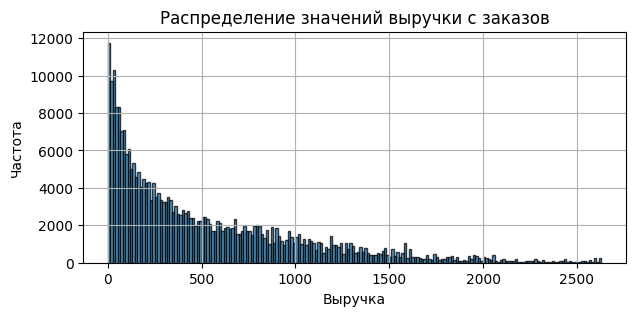

In [24]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(7, 3))

df['revenue_rub'].plot(
                kind='hist',
                bins=200, 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
)

# Настраиваем оформление графика
plt.title('Распределение значений выручки с заказов')
plt.xlabel('Выручка')
plt.ylabel('Частота')
plt.grid()

# Выводим график
plt.show()

По гистограмме наблюдаем, что нулевых значений достаточно много они могут искажать результаты по выручке, возьмём только положительные значения

In [25]:
df = df[df['revenue_rub'] > 0]

Построим гистограмму заново, без учёта нулевых значений

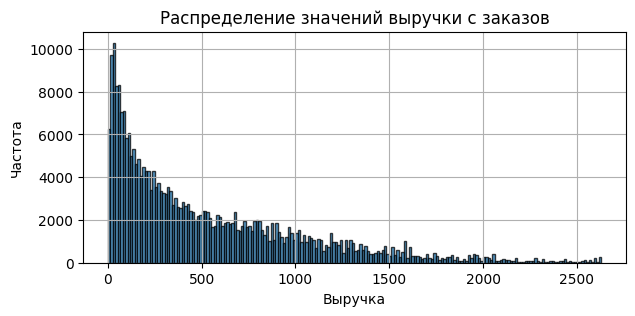

In [26]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(7, 3))

df['revenue_rub'].plot(
                kind='hist',
                bins=200, 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
)

# Настраиваем оформление графика
plt.title('Распределение значений выручки с заказов')
plt.xlabel('Выручка')
plt.ylabel('Частота')
plt.grid()

# Выводим график
plt.show()

Далее проведём анализ поля `tickets_count`

In [27]:
# выведем основные статистические характеристики поля
df['tickets_count'].describe()

count    281879.000000
mean          2.744117
std           1.157190
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          47.000000
Name: tickets_count, dtype: float64

По характеристикам видим что максимальное значение аномально высокое, построим гистограмму и диаграмму размаха для доп оценки колиечества аномалий

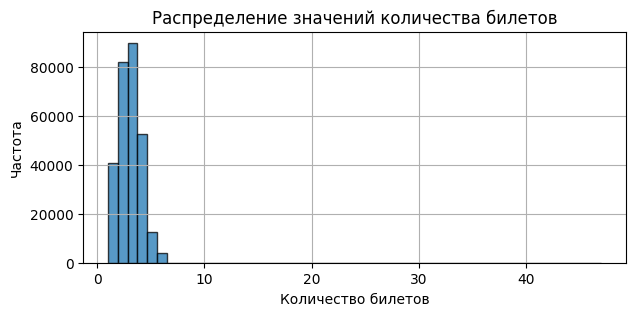

In [28]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(7, 3))

df['tickets_count'].plot(
                kind='hist',
                bins=50, 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
)

# Настраиваем оформление графика
plt.title('Распределение значений количества билетов')
plt.xlabel('Количество билетов')
plt.ylabel('Частота')
plt.grid()

# Выводим график
plt.show()

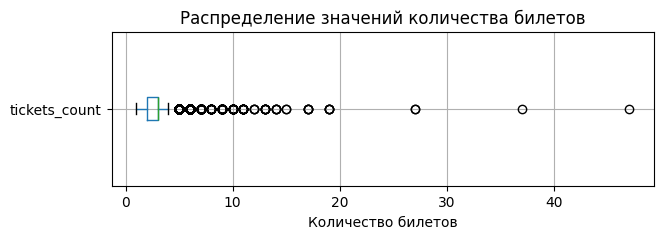

In [29]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='tickets_count', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений количества билетов')
plt.xlabel('Количество билетов')

# Выводим график
plt.show()

По полученным графикам видим, что, действительно имеются выбросы по количеству билетов в некоторых заказах, для того, чтобы избежать искажения анализа, отфильтруем значения выше 20

In [30]:
df = df[df['tickets_count'] < 15]

Выведем снова гистограмму распределения по количеству заказов и диаграмму размаха

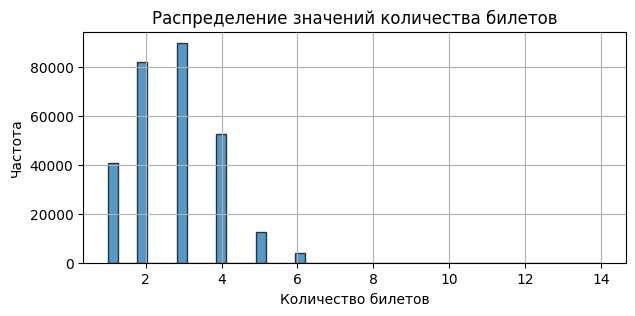

In [31]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(7, 3))

df['tickets_count'].plot(
                kind='hist',
                bins=50, 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
)

# Настраиваем оформление графика
plt.title('Распределение значений количества билетов')
plt.xlabel('Количество билетов')
plt.ylabel('Частота')
plt.grid()

# Выводим график
plt.show()

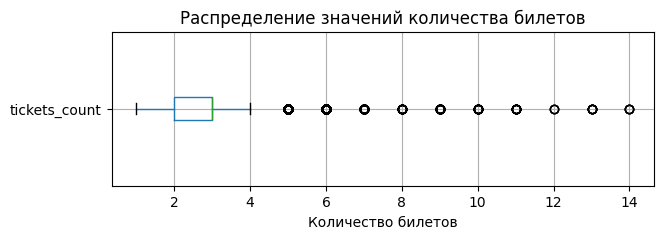

In [32]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='tickets_count', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений количества билетов')
plt.xlabel('Количество билетов')

# Выводим график
plt.show()

Теперь по графикам видим, что подавляющая часть аномальных значений отфильтрована и не повлияет на результаты анализа.

Выведем информацию по обработанному датасету

In [33]:
df.info()

<class 'pandas.DataFrame'>
Index: 281865 entries, 197386 to 266597
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype        
---  ------                 --------------   -----        
 0   user_id                281865 non-null  str          
 1   device_type_canonical  281865 non-null  str          
 2   order_id               281865 non-null  int32        
 3   order_dt               281865 non-null  datetime64[s]
 4   order_ts               281865 non-null  datetime64[s]
 5   currency_code          281865 non-null  str          
 6   revenue                281865 non-null  float64      
 7   tickets_count          281865 non-null  int8         
 8   days_since_prev        260475 non-null  Int16        
 9   event_id               281865 non-null  int32        
 10  service_name           281865 non-null  str          
 11  event_type_main        281865 non-null  str          
 12  region_name            281865 non-null  str          
 13  city_name 

**Промежуточный вывод**

В результате предобработки было отфильтровано `14 447` записей (в исходной выгрузке было `290 611` записей, стало `276 164`), что составляет менее `5%` от всего количества записей. 
Был создан столбец `revenue_rub`, который позволит проводить анализ в одной валюте - рублях.

Таким образом, большая часть данных сохранена и при этом анализ данных будет более качественный с минимальным искажением.

---
---
### 3. Создание профиля пользователя



----

**Задача 3.1.** Построение профиля пользователя


Перед построением профиля пользователя отсоритируем данные по времени совершения заказа, что позволит нам использовать это при поиске агрегированных признаков (методы `first` и `last`)

In [34]:
# сортировка по времени создания заказа
df = df.sort_values('order_ts')

# для наглядности выведем первые 5 записей
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name,revenue_rub
285282,fd4d47438ebb946,mobile,7565637,2024-06-01,2024-06-01 00:00:42,rub,1083.15,4,0,131671,прачечная,театр,каменевский_регион,глиногорск,1083.15
285283,fd4d47438ebb946,mobile,7565521,2024-06-01,2024-06-01 00:01:30,rub,812.36,3,0,131671,прачечная,театр,каменевский_регион,глиногорск,812.36
118843,57ef0a1905ac488,mobile,6670842,2024-06-01,2024-06-01 00:01:58,rub,2091.31,4,<NA>,375861,билеты_в_руки,театр,лесодальний_край,родниковец,2091.31
285281,fd4d47438ebb946,mobile,7565550,2024-06-01,2024-06-01 00:03:13,rub,812.36,3,0,131671,прачечная,театр,каменевский_регион,глиногорск,812.36
264552,e73089d7d016cd8,mobile,5502055,2024-06-01,2024-06-01 00:03:34,rub,181.39,2,0,211846,прачечная,театр,широковская_область,радужнополье,181.39


Вычислим для каждого пользователя агрегированные признаки:
- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия;
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

Данные запишем в `gr_users`

In [35]:
gr_users = df.groupby('user_id').agg(
    first_order_dt=('order_dt', 'first'),
    last_order_dt=('order_dt', 'last'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service=('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),    
    cnt_orders=('order_id', 'count'),
    avg_revenue=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean'),
    avg_between_days=('days_since_prev', 'mean')
).reset_index()

# выведем полученные данные для наглядности
gr_users.head()

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,cnt_orders,avg_revenue,avg_tickets,avg_between_days
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский_регион,край_билетов,театр,1,1521.940000,4.000000,<NA>
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский_регион,мой_билет,выставки,2,774.010000,3.000000,75.0
2,000898990054619,2024-07-13,2024-10-23,mobile,североярская_область,лови_билет!,другое,3,767.213333,2.666667,51.0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский_регион,край_билетов,театр,1,917.830000,4.000000,<NA>
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский_край,лучшие_билеты,театр,2,61.310000,1.500000,16.0


Добавим бинарные признаки `is_two` и `is_five` в профиль пользователей

In [36]:
# добавление бинарного признака is_two
gr_users['is_two'] = (gr_users['cnt_orders'] >= 2).astype(int)

# добавление бинарного признака is_five
gr_users['is_five'] = (gr_users['cnt_orders'] >= 5).astype(int)

# выведем полученные данные для наглядности
gr_users.head()

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,cnt_orders,avg_revenue,avg_tickets,avg_between_days,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский_регион,край_билетов,театр,1,1521.940000,4.000000,<NA>,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский_регион,мой_билет,выставки,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,североярская_область,лови_билет!,другое,3,767.213333,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский_регион,край_билетов,театр,1,917.830000,4.000000,<NA>,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский_край,лучшие_билеты,театр,2,61.310000,1.500000,16.0,1,0


Округлим полученные результаты для столбцов с средними значениями, т.к. нам не требуется такая высокая точность

In [37]:
# округление до сотых поля avg_revenue
gr_users['avg_revenue'] = gr_users['avg_revenue'].round(2)

# округление до сотых поля avg_tickets
gr_users['avg_tickets'] = gr_users['avg_tickets'].round(2)

# округление до десятых поля avg_between_days
gr_users['avg_between_days'] = gr_users['avg_between_days'].round(1)

# выведем полученные данные для наглядности
gr_users.head()

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,cnt_orders,avg_revenue,avg_tickets,avg_between_days,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский_регион,край_билетов,театр,1,1521.94,4.00,<NA>,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский_регион,мой_билет,выставки,2,774.01,3.00,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,североярская_область,лови_билет!,другое,3,767.21,2.67,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский_регион,край_билетов,театр,1,917.83,4.00,<NA>,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский_край,лучшие_билеты,театр,2,61.31,1.50,16.0,1,0


---

**Задача 3.2.** Знакомство с профилями пользователей

Проверим репрезентативны ли данные и нет ли в них аномалий.


По данным о профилях пользователей, рассчитаем:
- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

In [38]:
# получим общее число пользователей в выборке
total_users = len(gr_users['user_id'])
f'Общее число пользователей: {total_users}'

'Общее число пользователей: 21700'

In [39]:
# получим среднюю выручку с одного заказа
avg_revenue_order = gr_users['avg_revenue'].mean()

f'Средняя выручка с одного заказа: {avg_revenue_order:.2f}'

'Средняя выручка с одного заказа: 551.89'

In [40]:
# получим долю пользователей, совершивших 2 и более заказа
relation_two_order = gr_users['is_two'].mean()
# avg_revenue_order = gr_users['is_five'].mean()
	
f'Долю пользователей, совершивших 2 и более заказа: {relation_two_order:.2%}'

'Долю пользователей, совершивших 2 и более заказа: 61.67%'

In [41]:
# получим долю пользователей, совершивших 2 и более заказа
relation_five_order = gr_users['is_five'].mean()
	
f'Долю пользователей, совершивших 5 и более заказов: {relation_five_order:.2%}'

'Долю пользователей, совершивших 5 и более заказов: 28.87%'

Рассчитаем статистические показатели по общему количеству заказов

In [42]:
gr_users['cnt_orders'].describe()

count    21700.000000
mean        12.989171
std        119.748831
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       9986.000000
Name: cnt_orders, dtype: float64

По данным видим, что имеются аномальное значение по количеству заказов. Построим дополнительно диграмму размаха для наглядности

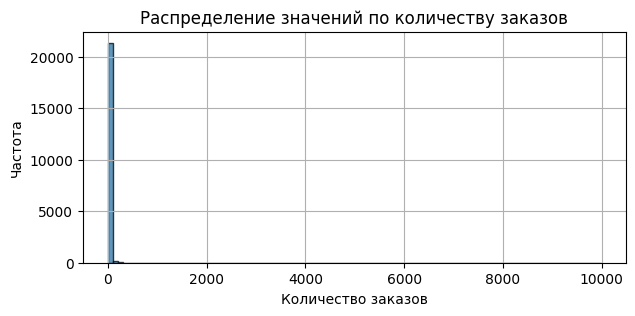

In [43]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(7, 3))

gr_users['cnt_orders'].plot(
                kind='hist',
                bins=100, 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
)

# Настраиваем оформление графика
plt.title('Распределение значений по количеству заказов')
plt.xlabel('Количество заказов')
plt.ylabel('Частота')
plt.grid()

# Выводим график
plt.show()

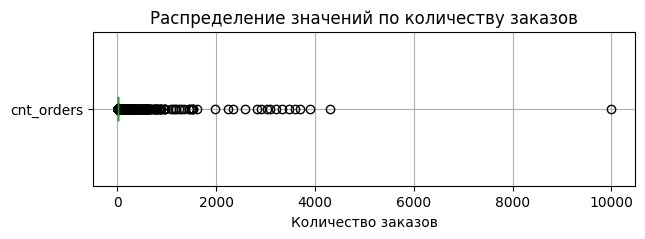

In [44]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
gr_users.boxplot(column='cnt_orders', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений по количеству заказов')
plt.xlabel('Количество заказов')

# Выводим график
plt.show()

По диграмме размаха видим, что аномальных значений немного, но они существенно искажают статистические показатели, отфильтруем их по 95-му процентилю, чтобы исключить большуя часть аномальных значений

In [45]:
gr_cnt_order_p_95 = gr_users['cnt_orders'].quantile(0.95)
gr_users = gr_users[gr_users['cnt_orders']< gr_cnt_order_p_95]

Теперь заново построим диаграмму размаха и гистограмму распределений

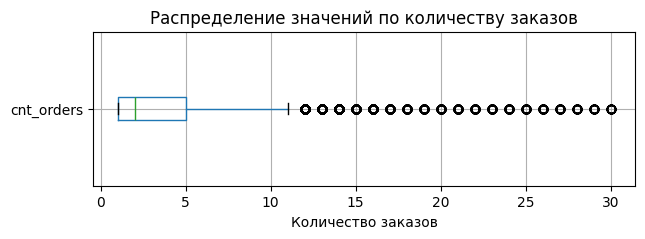

In [46]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
gr_users.boxplot(column='cnt_orders', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений по количеству заказов')
plt.xlabel('Количество заказов')

# Выводим график
plt.show()

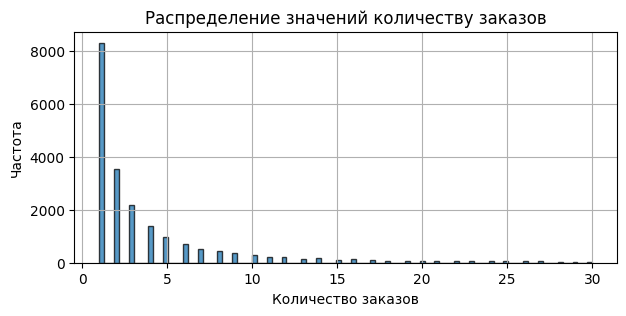

In [47]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(7, 3))

gr_users['cnt_orders'].plot(
                kind='hist',
                bins=100, 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
)

# Настраиваем оформление графика
plt.title('Распределение значений количеству заказов')
plt.xlabel('Количество заказов')
plt.ylabel('Частота')
plt.grid()

# Выводим график
plt.show()

Выведем заново статистические показатели по количеству заказов

In [48]:
gr_users['cnt_orders'].describe()

count    20596.000000
mean         3.991406
std          4.978192
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max         30.000000
Name: cnt_orders, dtype: float64

После фильтрации видим, что теперь искажение результатов будет минимальным, так как аномальные значения по количеству заказов исключены, количества значений составляет больше 20 000, этих данных будет достаточно для анализа

Проанализируем среднее число билетов в заказе, ознакомимся с статистическими показателями по этому полю

In [49]:
gr_users['avg_tickets'].describe()

count    20596.000000
mean         2.746349
std          0.935316
min          1.000000
25%          2.000000
50%          2.750000
75%          3.170000
max         11.000000
Name: avg_tickets, dtype: float64

Дополнительно выведем диаграмму размаха

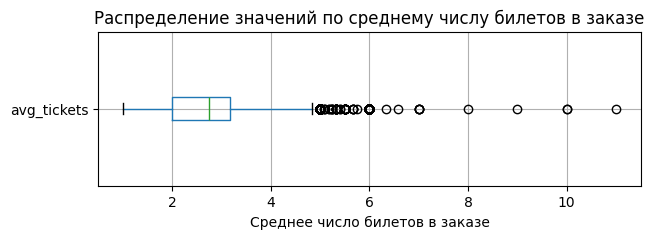

In [50]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
gr_users.boxplot(column='avg_tickets', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений по среднему числу билетов в заказе')
plt.xlabel('Среднее число билетов в заказе')

# Выводим график
plt.show()

Для поля `avg_tickets` значительного количества аномальных значений не выявлено, при этом среднее значение и медина близки между собой, небольшие выбросы после 75-го процентиля не будем отфильтровывать, т.к. влияние минимально

Познакомимся с статичтическими показателями среднего количества дней между покупками

In [51]:
gr_users['avg_between_days'].describe()

count      12347.0
mean     17.143776
std      22.939016
min            0.0
25%            1.0
50%            9.5
75%           22.4
max          148.0
Name: avg_between_days, dtype: Float64

Построим гистограмму и диаграмму размаха

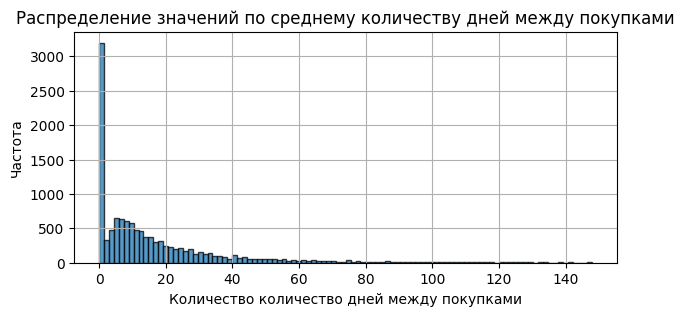

In [52]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(7, 3))

gr_users['avg_between_days'].plot(
                kind='hist',
                bins=100, 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
)

# Настраиваем оформление графика
plt.title('Распределение значений по среднему количеству дней между покупками')
plt.xlabel('Количество количество дней между покупками')
plt.ylabel('Частота')
plt.grid()

# Выводим график
plt.show()

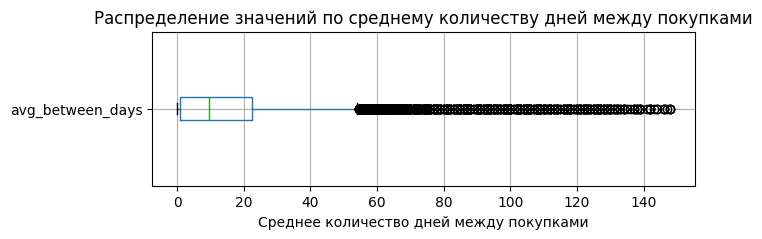

In [53]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
gr_users.boxplot(column='avg_between_days', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений по среднему количеству дней между покупками')
plt.xlabel('Среднее количество дней между покупками')

# Выводим график
plt.show()

По результатам видим, что значительных аномалий не выявлено, большие значения похожи на естественное распределение, значительного влияния они не окажут на дальнейший анализ, оставим как есть

Посчитаем сколько записей было отфильтровано из-за аномально высоких значений

In [54]:
len(gr_users)

20596

После фильтрации анмальных значений осталось 20596, было 21700, найдём долю отсеянных данных

In [55]:
round(100*(21700 - 20596)/21700, 2)

5.09

По итогам фильтрации было отсеяно 5,09% записей, что не является критичным для качественного дальнейшего анализа, и благодаря проведённой фильтрации исключенные аномальные значения, которые исказили бы наши результаты

---
---

### 4. Исследовательский анализ данных

Исследуем признаки, влияющие на возврат пользователей, для этого будем использовать полученные профили пользователей.


#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу


---

**Задача 4.1.1.** Изучим распределение пользователей по признакам.

для удобства выведем несколько первых записей из датасета по профилям пользователей

In [56]:
gr_users.head()

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,cnt_orders,avg_revenue,avg_tickets,avg_between_days,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский_регион,край_билетов,театр,1,1521.94,4.00,<NA>,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский_регион,мой_билет,выставки,2,774.01,3.00,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,североярская_область,лови_билет!,другое,3,767.21,2.67,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский_регион,край_билетов,театр,1,917.83,4.00,<NA>,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский_край,лучшие_билеты,театр,2,61.31,1.50,16.0,1,0


Сгруппируем пользователей по типу их первого мероприятия

In [57]:
# сгруппируем по типу первого мероприятия
gr_event_type = gr_users.groupby('first_event_type').agg(
    cnt_user=('user_id', 'count')
).reset_index()

# рассчитаем общее количество пользователей
total_users_type = gr_event_type['cnt_user'].sum()

# добавим столбец с долями
gr_event_type['percent'] = (100 * gr_event_type['cnt_user']/total_users_type).round(2)

# отсортируем и выведем результаты
gr_event_type.sort_values('cnt_user', ascending=False)

,first_event_type,cnt_user,percent
2,концерты,9222,44.78
1,другое,4987,24.21
5,театр,4075,19.79
4,стендап,1077,5.23
3,спорт,738,3.58
0,выставки,401,1.95
6,ёлки,96,0.47


Исходя из группировки по типу первого мероприятия данные распределены не равномерно, большая часть пользователей начала свой путь с категории `конценты` - 44,78%, затем идёт категория `другое`(24,21%) и `театры`(19,79%) а самая меньшая часть с `ёлок`(0,47%)

Проанализируем распределение по типу первого устройства 

In [58]:
# сгруппируем по типу первого устройства
gr_device = gr_users.groupby('first_device').agg(
    cnt_user=('user_id', 'count')
).reset_index()

# рассчитаем общее количество пользователей
total_users_device = gr_device['cnt_user'].sum()

# добавим столбец с долями
gr_device['percent'] = (100 * gr_device['cnt_user']/total_users_device).round(2)

# отсортируем и выведем результаты
gr_device.sort_values('cnt_user', ascending=False)

,first_device,cnt_user,percent
1,mobile,17091,82.98
0,desktop,3505,17.02


По полученным данным видим, что в подавляющем большинстве первым устройством является `mobile`(82.98%), таким образом распределение по типу первого устройства также не равномерно

Выполним анализ распределения по региону проведения мероприятия из первого заказа

In [59]:
# сгруппируем по региону проведения мероприятия из первого заказа
gr_region = gr_users.groupby('first_region').agg(
    cnt_user=('user_id', 'count')
).reset_index()

# рассчитаем общее количество пользователей
total_users_region = gr_region['cnt_user'].sum()

# добавим столбец с долями
gr_region['percent'] = (100 * gr_region['cnt_user']/total_users_region).round(2)

# отсортируем и выведем результаты
gr_region.sort_values('cnt_user', ascending=False)

,first_region,cnt_user,percent
23,каменевский_регион,6681,32.44
60,североярская_область,3609,17.52
77,широковская_область,1192,5.79
45,озернинский_край,661,3.21
41,малиновоярский_округ,517,2.51
...,...,...,...
17,залесский_край,2,0.01
5,верхозёрский_край,1,0.00
56,светолесский_край,1,0.00
66,сосноводолинская_область,1,0.00


По региону проведения мероприятия из первого заказа также видим, что распределение пользователей не равномерное, больше всего пользователей в `каменевский_регион` (32,44%) и `североярская_область` (17,52%), в остальных регионах пользователей значительно меньше

Познакомимся с распределением по билетному оператору, продавшему билеты на первый заказ

In [60]:
# сгруппируем по билетному оператору, продавшему билеты на первый заказ
gr_service = gr_users.groupby('first_service').agg(
    cnt_user=('user_id', 'count')
).reset_index()

# рассчитаем общее количество пользователей
total_users_service = gr_service['cnt_user'].sum()

# добавим столбец с долями
gr_service['percent'] = (100 * gr_service['cnt_user']/total_users_service).round(2)

# отсортируем и выведем результаты
gr_service.sort_values('cnt_user', ascending=False)

,first_service,cnt_user,percent
3,билеты_без_проблем,4768,23.15
22,мой_билет,2875,13.96
19,лови_билет!,2693,13.08
4,билеты_в_руки,2410,11.70
23,облачко,2125,10.32
7,весь_в_билетах,1236,6.00
20,лучшие_билеты,1132,5.50
24,прачечная,552,2.68
17,край_билетов,443,2.15
12,дом_культуры,341,1.66


По распределению пользользователей взависимости от первого билетного оператора также не отслеживается равномерности, больше всего пользователей совершили первые заказы у операторов `билеты_без_проблем` (23.15%), `мой_билет` (13.96%), `лови_билет!` (13.08%), `билеты_в_руки` (11.70%), `облачко` (10.32%)

По результатам анализа распределения пользователей по признакам следует, что распределение - не равномерное, имеются выраженные "точки входа"

---

**Задача 4.1.2.** Проанализируем возвраты пользователей:

Перегруппируем данные добавив данные по повторным заказам

In [61]:
# пересоздадим группировку с учётом количества заказов
gr_event_type = gr_users.groupby('first_event_type').agg(
    cnt_user=('user_id', 'count'),
    perc_repeat=('is_two', 'mean')
).reset_index()

# переведём в проценты для наглядности
gr_event_type['perc_repeat'] = (gr_event_type['perc_repeat'] * 100).round(2)

# отсортируем и выведем результаты
gr_event_type = gr_event_type.sort_values('perc_repeat', ascending=False)

gr_event_type

,first_event_type,cnt_user,perc_repeat
0,выставки,401,63.09
5,театр,4075,61.84
2,концерты,9222,60.18
4,стендап,1077,59.42
1,другое,4987,57.51
6,ёлки,96,56.25
3,спорт,738,53.25


Построим визуализацию возратов пользователей по типу первого мероприятия

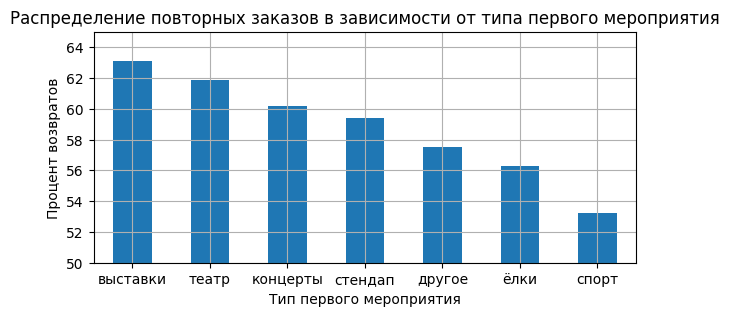

In [62]:
# Строим диаграмму
gr_event_type.plot(
    kind='bar', 
    x='first_event_type',
    y='perc_repeat',
    rot=0,
    legend=False, 
    xlabel='Тип первого мероприятия',
    ylabel='Процент возвратов',
    ylim=(50, 65),
    title='Распределение повторных заказов в зависимости от типа первого мероприятия',
    figsize=(7, 3)
)

plt.grid(True)

plt.show()

Пользователи, которые начинают с выставок, театра или концертов, возвращаются чаще других, а самый низкий показатель возвратов - спорт

Перегруппируем данные по первому устройству и возвратам пользователей

In [63]:
# пересоздадим группировку с учётом количества заказов
gr_device = gr_users.groupby('first_device').agg(
    cnt_user=('user_id', 'count'),
    perc_repeat=('is_two', 'mean')
).reset_index()

# переведём в проценты для наглядности
gr_device['perc_repeat'] = (gr_device['perc_repeat'] * 100).round(2)

# отсортируем и выведем результаты
gr_device = gr_device.sort_values('perc_repeat', ascending=False)

gr_device

,first_device,cnt_user,perc_repeat
0,desktop,3505,61.74
1,mobile,17091,59.18


Построим визуализацию возратов пользователей по типу первого устройства

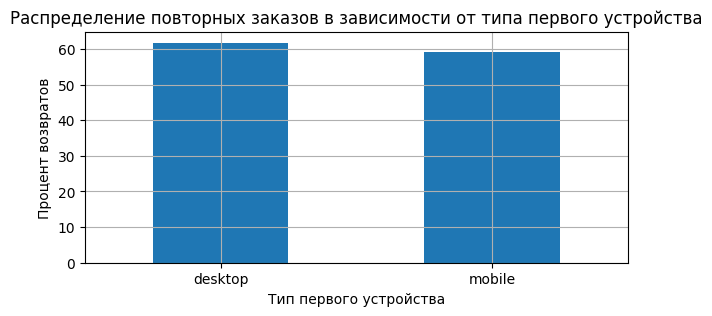

In [64]:
# Строим диаграмму
gr_device.plot(
    kind='bar', 
    x='first_device',
    y='perc_repeat',
    rot=0,
    legend=False, 
    xlabel='Тип первого устройства',
    ylabel='Процент возвратов',
    title='Распределение повторных заказов в зависимости от типа первого устройства',
    figsize=(7, 3)
)

plt.grid(True)

plt.show()

Пользователи `desktop` возвращаются чаще `mobile` пользователей

Перегруппируем данные по региону проведения мероприятия и возвратам пользователей

In [65]:
# пересоздадим группировку по региону проведения мероприятия
gr_region = gr_users.groupby('first_region').agg(
    cnt_user=('user_id', 'count'),
    perc_repeat=('is_two', 'mean')
).reset_index()

# переведём в проценты для наглядности
gr_region['perc_repeat'] = (gr_region['perc_repeat'] * 100).round(2)

# отсортируем и отфильтруем по колиечеству пользователей топ 10
gr_region = gr_region.sort_values('cnt_user', ascending=False).head(10)

# отсортируем по доли возвратов и выведем результаты
gr_region = gr_region.sort_values('perc_repeat', ascending=False)

gr_region

,first_region,cnt_user,perc_repeat
76,шанырский_регион,425,66.59
57,светополянский_округ,440,64.09
77,широковская_область,1192,63.26
60,североярская_область,3609,62.32
52,речиновская_область,425,62.12
23,каменевский_регион,6681,60.25
74,травяная_область,440,59.77
78,яблоневская_область,397,57.93
41,малиновоярский_округ,517,54.93
45,озернинский_край,661,54.01


Построим визуализацию возратов пользователей по региону проведения первого мероприятия

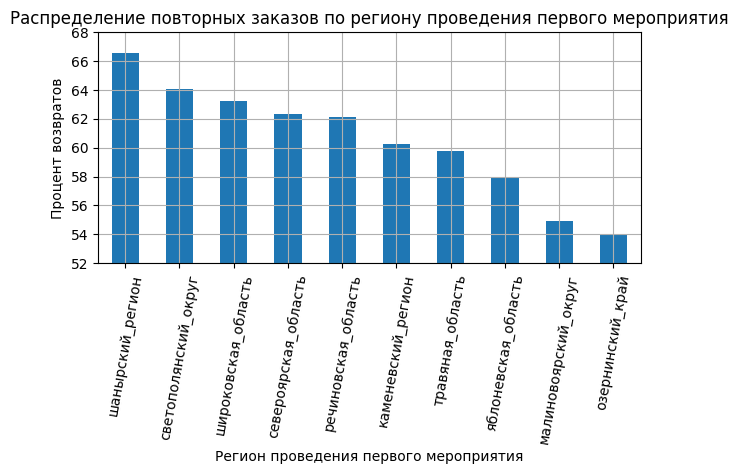

In [66]:
# Строим диаграмму
gr_region.plot(
    kind='bar', 
    x='first_region',
    y='perc_repeat',
    rot=80,
    legend=False, 
    xlabel='Регион проведения первого мероприятия',
    ylabel='Процент возвратов',
    title='Распределение повторных заказов по региону проведения первого мероприятия',
    ylim=(52, 68),
    figsize=(7, 3)
)

plt.grid(True)

plt.show()

`Шанырский_регион` - лидер по повторным заказам. Далее  на близком уровне идут `светополянский_округ` и `широковская_область`

Перегруппируем данные по билетному оператору, продавшему билеты на первый заказ

In [67]:
# пересоздадим группировку по билетному оператору
gr_service = gr_users.groupby('first_service').agg(
    cnt_user=('user_id', 'count'),
    perc_repeat=('is_two', 'mean')
).reset_index()

# переведём в проценты для наглядности
gr_service['perc_repeat'] = (gr_service['perc_repeat'] * 100).round(2)

# отсортируем и отфильтруем по колиечеству пользователей топ 10
gr_service = gr_service.sort_values('cnt_user', ascending=False).head(10)

# отсортируем по доли возвратов и выведем результаты
gr_service = gr_service.sort_values('perc_repeat', ascending=False)

gr_service

,first_service,cnt_user,perc_repeat
17,край_билетов,443,64.11
12,дом_культуры,341,63.05
7,весь_в_билетах,1236,61.25
4,билеты_в_руки,2410,60.83
24,прачечная,552,60.33
23,облачко,2125,60.05
20,лучшие_билеты,1132,59.72
19,лови_билет!,2693,59.56
22,мой_билет,2875,59.13
3,билеты_без_проблем,4768,58.07


Построим визуализацию возратов пользователей по билетному оператору

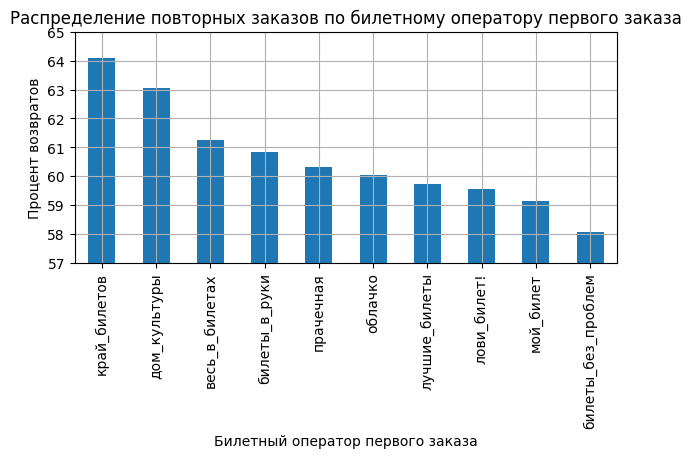

In [68]:
# Строим диаграмму
gr_service.plot(
    kind='bar', 
    x='first_service',
    y='perc_repeat',
    rot=90,
    legend=False, 
    xlabel='Билетный оператор первого заказа',
    ylabel='Процент возвратов',
    title='Распределение повторных заказов по билетному оператору первого заказа',
    ylim=(57, 65),
    figsize=(7, 3)
)

plt.grid(True)

plt.show()

Операторы `край_билетов` и `дом_культуры` самый высокий показатель по возврату пользователей

По результатам анализа видим, что имеются выраженные точки входа, так как сегмент, в котором пользователи совершают повторный заказ чаще чем в среднем по выборке

---

**Задача 4.1.3.** Опираясь на выводы из прошлых задач, проверим продуктовые гипотезы


**Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

Для наглядности выведем повторно визуализацию по типу первого мероприятия, но только для тех случаев, где первый заказ `спорт` и `концерты`

  first_event_type  cnt_user  perc_repeat
2         концерты      9222        60.18
3            спорт       738        53.25 





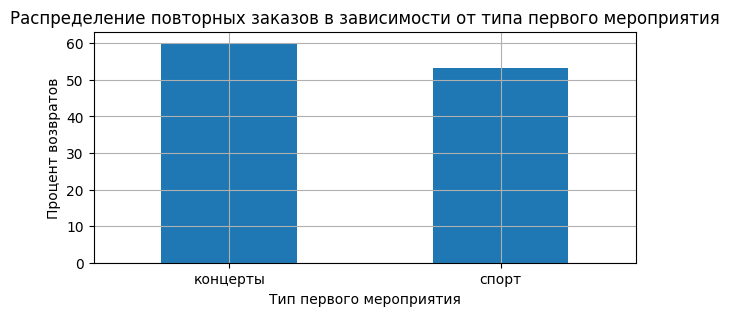

In [69]:

# отфильтруем данные по концертам и спорту
gr_event_type = gr_event_type[gr_event_type['first_event_type'].isin(['концерты', 'спорт'])]

# дополнительно выведем значния
print(gr_event_type, 3*'\n')

# Строим диаграмму
gr_event_type.plot(
    kind='bar', 
    x='first_event_type',
    y='perc_repeat',
    rot=0,
    legend=False, 
    xlabel='Тип первого мероприятия',
    ylabel='Процент возвратов',
    title='Распределение повторных заказов в зависимости от типа первого мероприятия',
    figsize=(7, 3)
)

plt.grid(True)

plt.show()

По выведенным данным и визуализации наглядно видим, что гипотеза не подтверждается, так как доля повторных заказов для пользователей, у которых первый заказ был на `концерты` заметно выше, чем у тех, у кого `спорт`

Проверим вторую гипотезу.

**Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

Для удобства выведем диграмму рассеяния

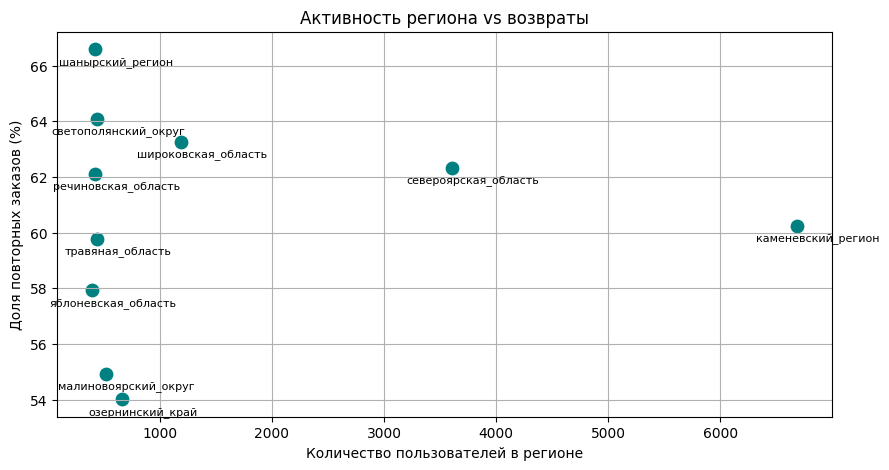

In [70]:
# создадим окно и оси 
fig, ax = plt.subplots(figsize=(10, 5))

# отсортируем по количеству пользователей
gr_region = gr_region.sort_values('cnt_user', ascending=False)

# строим диаграмму рассеяния
ax.scatter(gr_region['cnt_user'], gr_region['perc_repeat'], s=80, color='teal')

# отобразим подписи к точкам
for _, row in gr_region.iterrows():
    ax.annotate(
        row['first_region'], 
        (row['cnt_user'], row['perc_repeat']), 
        fontsize=8, 
        ha='center', 
        va='top', 
        xytext=(15, -5),
        textcoords='offset points'
    )

ax.set_xlabel('Количество пользователей в регионе')
ax.set_ylabel('Доля повторных заказов (%)')
ax.set_title('Активность региона vs возвраты')
ax.grid(True)

plt.show()

Из диаграммы видим, что вторая гипотеза также не подтверждается, так как не прослеживается линейная зависимость того, что чем выше активность региона, тем больше возвратов в нём и наоборот. Есть малые регионы с очень высокой долей возвратов, при этом есть также малые регионы с низкой долей возвратов, строгой зависимости возвратов от активности региона не прослеживается

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

---

**Задача 4.2.1.** Отследим связь между средней выручкой сервиса с заказа и повторными заказами.


Построим сравнительные гистограммы распределения средней выручки с билета

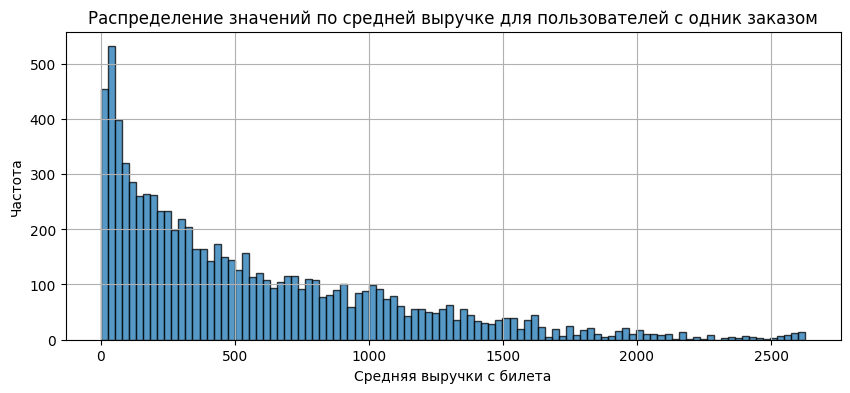

In [71]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(10, 4))

gr_users[gr_users['is_two']==0]['avg_revenue'].plot(
                kind='hist',
                bins=100, 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
                #density=True 
)

# Настраиваем оформление графика
plt.title('Распределение значений по средней выручке для пользователей с одник заказом')
plt.xlabel('Средняя выручки с билета')
plt.ylabel('Частота')
plt.grid()

# Выводим график
plt.show()

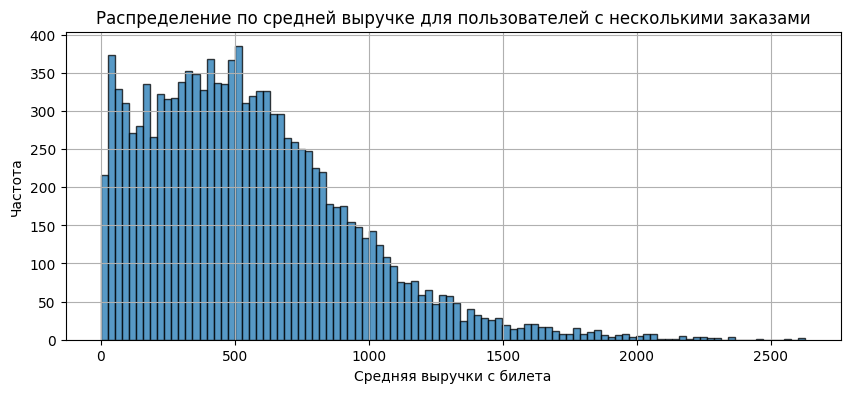

In [72]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(10, 4))

gr_users[gr_users['is_two']==1]['avg_revenue'].plot(
                kind='hist',
                bins=100, 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
                #density=True 
)

# Настраиваем оформление графика
plt.title('Распределение по средней выручке для пользователей с несколькими заказами')
plt.xlabel('Средняя выручки с билета')
plt.ylabel('Частота')
plt.grid()

# Выводим график
plt.show()

Концентрация пользователей, совершивших 1 заказ, находится в диапазоне средней выручке между 0 и 600 рублями, средни пользователей совершивших от 2 заказов между 0 и 1100 рублями. Средняя выручка в группах различается тем, что у пользователей с одним заказом, концентрация средней выручки смещена сильно в левуя часть, т.е. низких значений средней выручке, а у второй группы концентрация уже имеет бОльший диапазон, он больше почти в 2 раза, т.е. пользователи совершившие несколько заказов, приносят больше средней выручки

---

**Задача 4.2.2.** Сравним распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.


Начнём группы пользователей совершивших 2-4 заказа. Отфильтруем данные для интересующей группы и выведем гистограмму

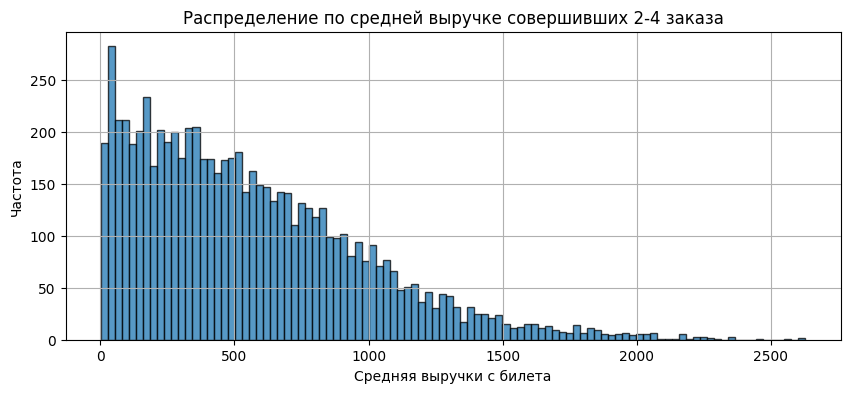

In [73]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(10, 4))

gr_users[(gr_users['is_two'] == 1) & (gr_users['is_five'] == 0)]['avg_revenue'].plot(
                kind='hist',
                bins=100, 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
                #density=True 
)

# Настраиваем оформление графика
plt.title('Распределение по средней выручке совершивших 2-4 заказа')
plt.xlabel('Средняя выручки с билета')
plt.ylabel('Частота')
plt.grid()

# Выводим график
plt.show()

Сделаем аналогичное для группы пользователей совершивших от 5 заказов

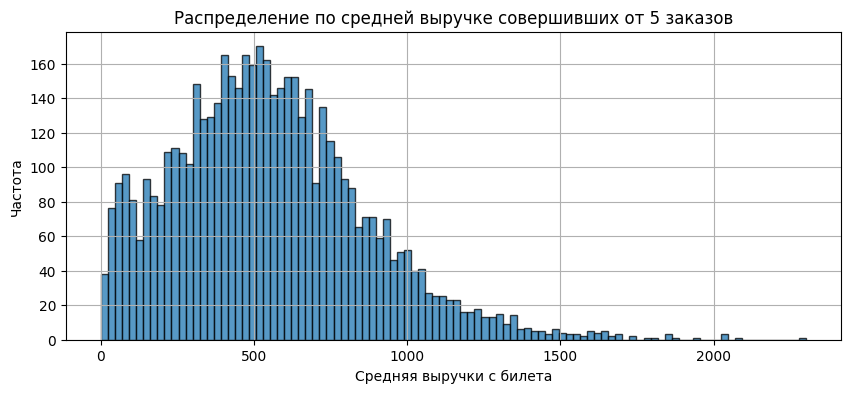

In [74]:
# отфильтруем данные для интересующей группы и выведем гистограмму
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(10, 4))

gr_users[gr_users['is_five'] == 1]['avg_revenue'].plot(
                kind='hist',
                bins=100, 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
                #density=True 
)

# Настраиваем оформление графика
plt.title('Распределение по средней выручке совершивших от 5 заказов')
plt.xlabel('Средняя выручки с билета')
plt.ylabel('Частота')
plt.grid()

# Выводим график
plt.show()


Ознакомившись с гистограммами распределений средней выручке по двум группам пользователей видим, что  между группами пользователей совершивших от 5 заказов и пользователей совершивших 2-4 заказа имеются различия. Так у группы совершившей 2-4 заказа данные сконцентрированы ближе к левому краю, а у группы совершей от 5 заказов вправо, это говорит о том, что пользователи совершившие от 5 заказов приносят в среднем большую выручку, чем вторая группа, при этом у первой группы низкой средней выручке меньше, чем у второй, при этом пользователей совершающих меньше заказов больше по количеству

---

**Задача 4.2.3.** Проанализируем влияние среднего количества билетов в заказе на вероятность повторной покупки.


Изучим распределение пользователей по среднему количеству билетов в заказе. Выполним сегментацию пользователей по среднему количеству билетов в заказе:
- от 1 до 2 билетов;
- от 2 до 3 билетов;
- от 3 до 5 билетов;
- от 5 и более билетов.

In [75]:
# напишем функцию для сегментации
def avg_tick_cnt(value):
    if 1 <= value < 2:
        return 'от 1 до 2 билетов'
    elif 2 <= value < 3:
        return 'от 2 до 3 билетов'
    elif 3 <= value < 5:
        return 'от 3 до 5 билетов'
    elif value >=5:
        return 'от 5 и более билетов'
    else:
        return None

# применим функцию для сегментации пользователей    
gr_users['avg_tickets_count'] = gr_users['avg_tickets'].apply(avg_tick_cnt)

Для каждого сегмента подсчитаем общее число пользователей и долю пользователей, совершивших повторные заказы.

In [76]:
# создадим группировку по для подсчёта
gr_segment_tick = gr_users.groupby('avg_tickets_count').agg(
    cnt_users=('user_id', 'count'), # сколько всего пользователей в сегменте
    cnt_repeat=('is_two', 'sum'), # количество пользователей совершивших от 2х заказов
    relation_repeat=('is_two', 'mean') # доля пользователей совершивших от 2х заказов
).reset_index()

# для удоства долю переведём в проценты
gr_segment_tick['relation_repeat'] = (100 * gr_segment_tick['relation_repeat']).round(2)

gr_segment_tick = gr_segment_tick.sort_values('cnt_repeat', ascending=False)
# выведем
gr_segment_tick

,avg_tickets_count,cnt_users,cnt_repeat,relation_repeat
1,от 2 до 3 билетов,8663,6166,71.18
2,от 3 до 5 билетов,8890,4769,53.64
0,от 1 до 2 билетов,2387,1220,51.11
3,от 5 и более билетов,656,123,18.75


Исходя из данных пользователи расположены по сегментам неравномерно, больше всего пользователей в двух сегментах: `от 2 до 3 билетов` и `от 3 до 5 билетов`, таким образом пользователеи сконцентрированны в этих двух сегментах. Самый маленький по количеству пользователей сегмент от `5 и более билетов`.
Среди сегментов выделяются два сегмета, в которых доля повторных заказов имеет аномальные значения. Сегмент `от 2 до 3 билетов` имеет аномально высокую долю пользователей совершивших повторные заказы, а сегмент `5 и более билетов` имеет аномально низкое значение доли пользователей с повторными заказами.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучим временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.



---

**Задача 4.3.1.** Проанализируем, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.


По дате первого заказа выделим день недели и запишем в поле `weekday_name`

In [77]:
gr_users['weekday_name'] = gr_users['first_order_dt'].dt.day_name()

Сгруппируем данные по дням недели и вычислим общее число пользователей и долю пользователей, совершивших повторные заказы

In [78]:
# группировка
gr_segment_weekday = gr_users.groupby('weekday_name').agg(
    cnt_users=('user_id', 'count'), # сколько всего пользователей в сегменте
    cnt_repeat=('is_two', 'sum'), # количество пользователей совершивших от 2х заказов
    relation_repeat=('is_two', 'mean') # доля пользователей совершивших от 2х заказов
).reset_index()

# переведём долю в проценты для удобства
gr_segment_weekday['relation_repeat'] = (100 * gr_segment_weekday['relation_repeat']).round(2)

# выведем данные
gr_segment_weekday

,weekday_name,cnt_users,cnt_repeat,relation_repeat
0,Friday,3131,1836,58.64
1,Monday,2793,1709,61.19
2,Saturday,3093,1868,60.39
3,Sunday,2616,1518,58.03
4,Thursday,3008,1753,58.28
5,Tuesday,3005,1797,59.80
6,Wednesday,2950,1797,60.92


Добавим визуализацию

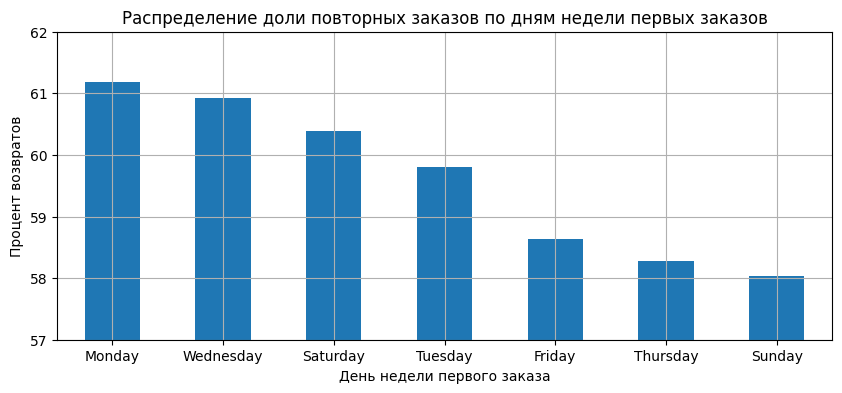

In [79]:

# Строим диаграмму
gr_segment_weekday.sort_values('relation_repeat', ascending=False).plot(
    kind='bar', 
    x='weekday_name',
    y='relation_repeat',
    rot=0,
    legend=False, 
    xlabel='День недели первого заказа',
    ylabel='Процент возвратов',
    ylim=(57, 62),
    title='Распределение доли повторных заказов по дням недели первых заказов',
    figsize=(10, 4)
)

plt.grid(True)

plt.show()

Ознакомившись с данными и визуализацией распределения доли повторных заказов по дням недели первых заказов, видим, что пользователи совершившие первые заказы в понедельники и среды возвращаются чаще, чем пользователи совершающие заказы в другие дни. Самый низкий процент возвратов у воскресенья, таким образом, день недели влияет на вероятность возврата клиента.

---

**Задача 4.3.2.** Изучим, как средний интервал между заказами влияет на удержание клиентов.


Добавим маркерный столбец, по количеству совершивших заказов `category_orders_cnt`

In [80]:
# создадим функцию для категоризации
def category_order_cnt(row):
    is_two = row['is_two']
    is_five = row['is_five']

    if (is_two == 1) and (is_five == 0):
        return 'совершившие 2–4 заказа'
    elif is_five == 1:
        return 'совершившие 5 и более заказов'
    else:
        return 'совершившие 1 заказ'

# применим функцию        
gr_users['category_orders_cnt'] = gr_users.apply(category_order_cnt, axis=1)


Сгруппируем данные по двум полученным категориям

In [81]:
gr_segment_order_cnt = gr_users[gr_users['category_orders_cnt'] != 'совершившие 1 заказ'].groupby('category_orders_cnt').agg(
    avg_days_for_cat=('avg_between_days', lambda x: round(x.mean(),2))
).reset_index()

gr_segment_order_cnt

,category_orders_cnt,avg_days_for_cat
0,совершившие 2–4 заказа,21.23
1,совершившие 5 и более заказов,11.15


По рассчитанным данным видим, что чем меньше средний интервал между заказавми, тем больше вероятность повторных заказов

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучим, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого будем использовать универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.



---

**Задача 4.4.1:** Проведём корреляционный анализ:
- Рассчитаем коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`cnt_orders`)

In [82]:
# запишем ключевые столбцы в список
column = ['first_order_dt', 'last_order_dt', 'first_device', 'first_region', 'first_service', 'first_event_type', 'cnt_orders', 'avg_revenue', 'avg_tickets', 'avg_between_days', 'weekday_name']

# для построение матрицы корреляций будем использовать только интересующие столбцы
df_corr = gr_users[column].copy()

# обозначим интервальные данные
interval_cols = ['cnt_orders', 'avg_revenue', 'avg_tickets', 'avg_between_days']

# построим матрицу корреляций
phi_matrix = df_corr.phik_matrix(interval_cols=interval_cols).sort_values('cnt_orders', ascending=False)

# отобразим матрицу
phi_matrix

,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,cnt_orders,avg_revenue,avg_tickets,avg_between_days,weekday_name
cnt_orders,0.395017,0.398157,0.043590,0.014506,0.040884,0.035496,1.000000,0.264370,0.294963,0.486444,0.016137
avg_between_days,0.347990,0.144506,0.022881,0.097479,0.057176,0.051132,0.486444,0.107457,0.099403,1.000000,0.000000
last_order_dt,0.998888,1.000000,0.083877,0.347216,0.228210,0.160775,0.398157,0.238295,0.215795,0.144506,0.878973
first_order_dt,1.000000,0.998888,0.105754,0.467425,0.301879,0.259039,0.395017,0.219170,0.187476,0.347990,1.000000
avg_tickets,0.187476,0.215795,0.057235,0.169196,0.064675,0.099599,0.294963,0.453149,1.000000,0.099403,0.000000
avg_revenue,0.219170,0.238295,0.079529,0.367300,0.383737,0.331118,0.264370,1.000000,0.453149,0.107457,0.000000
first_device,0.105754,0.083877,1.000000,0.112576,0.083721,0.062005,0.043590,0.079529,0.057235,0.022881,0.071644
first_service,0.301879,0.228210,0.083721,0.697714,1.000000,0.587076,0.040884,0.383737,0.064675,0.057176,0.059967
first_event_type,0.259039,0.160775,0.062005,0.509834,0.587076,1.000000,0.035496,0.331118,0.099599,0.051132,0.080727
weekday_name,1.000000,0.878973,0.071644,0.148690,0.059967,0.080727,0.016137,0.000000,0.000000,0.000000,1.000000


                  cnt_orders
avg_between_days    0.486444
last_order_dt       0.398157
first_order_dt      0.395017
avg_tickets         0.294963
avg_revenue         0.264370
first_device        0.043590
first_service       0.040884
first_event_type    0.035496
weekday_name        0.016137
first_region        0.014506 





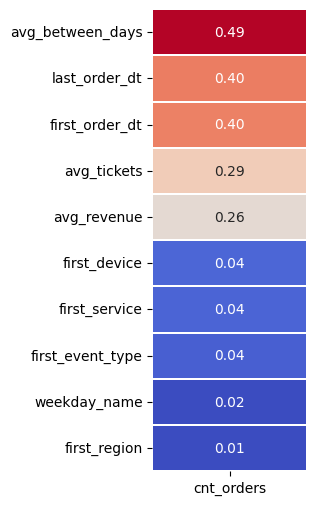

In [83]:
# подготовим данные для построения тепловой карты
data_heatmap = phi_matrix[phi_matrix.index != 'cnt_orders'][['cnt_orders']].sort_values(by='cnt_orders', ascending=False)

# отобразим данные
print(data_heatmap, 3*'\n')


# построим график
# укажем размеры графика
plt.figure(figsize=(2, 6))

# Построение тепловой диаграммы
sns.heatmap(
    data_heatmap,
    annot=True,
    cbar=False,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.3
)

# отобразим
plt.show()

Таким образом, наиболее связаные признаки с количеством заказов - `avg_between_days`, `last_order_dt`, `first_order_dt`(в порядке убывания 0.49, 0.40, 0.40), поля `avg_tickets` (0.29) и `avg_revenue` (0.26) имеют умеренную связь, а `first_device`, `first_service`, `first_event_type`, `weekday_name`, `first_region` имеют очень слабую связь, менее 0.05

### 5. Общий вывод и рекомендации

- **Информацию о данных**, выгруженные данные в большей части оказались корректными, предобработка была минимальной, важный момент в ней перевод выручки в единную валюту(была предоставлена в рублях и тенге). Пропуски в данных были только в одной колонке avg_between_days, связанно с особенностью формирования поля, предобработка поля не требовалась. Также была выполнена фильтрация выбросов для избежания искажения результатов анализа, т.к. встречались аномальные значения.

- **Основные результаты анализа.**, по итогам фильтрации в профиле пользователей осталось 20596 клиента. Пользователей распределили используя маркерные полонки `is_two` и `is_five`, (также был добавлен маркерный столбец `category_orders_cnt` маркирующий пользователей по количеству совершённых заказов), таким образом большая часть пользователей совершила только 1 заказ (8318), немного меньше 2-4 заказа (7118) и меньше всего совершила заказов группа от 5 заказов (5160), таким образом пользователи по количеству заказов распределены неравномерно. При изучении важными показателями являлись: средний промежуток между заказами(`avg_between_days`), тип мероприятия(`first_event_type`), средняя выручка(`avg_revenue`), билетный оператор (`first_service`) и регион(`first_region`)

- Более всего связаны такие признаки как:
    - тип мероприятия, так пользователи одних типов первыъ мероприятий возвращаются чаще других.
    - регион, также, пользователи из определённых регионов чаще возвращаются
    - также связан с возратом признак первый билетный оператор, видим, что что после покупок у определённых операторов возвратов больше
    - день недели даты первого заказа, в определённые дни недели видим количество возвратов выше других дней

- Средняя выручка связана с вероятностью повторных покупок таким образом, что чем больше средняя выручка, больше вероятность повторных покупок, при этом, фактически пользователей с низкой средней выручкой и малым количеством заказов больше по количеству. Линейной зависимости между количеством билетов и повторными заказами нет, при этом пользователи, которые в среднем покупают 2-3 билета возвращаются чаще остальных, меньше всего возращаются пользователи, которые покупают от 5 билетов
- Среди временных характеристи прослеживается зависимость повторных заказов с интервалами между покупками, чем меньше интервал, тем чаще возвращается клиент. Также видим, что пользователи, которые совершили первые покупки в определённые дни недели возвраю чаще других.
- По результатам корреляционного анализа сильная зависимость существует между повторными заказам и интервалом между заказами, первой и последними датами заказов, немного меньше связь с средней выручкой и средним количеством билетов в заказе.
      
**Рекомендации:**
- В первую очередь обратить на приоритетные сегменты
    - самые лояльные клиенты (от 5 заказов), предложить уникальные выгодные условия данному сегменту для удержания и прироста
    - перспективные клиенты (2-4 заказа), персональные предложения на основе первых покупок, добавить напоминация, мотивирующие на повторный заказ в рамках короткого интервала
    - изучить практику регионов с высоким возвратом, далее транслировать её на другие регионы
    - улучшить партнёрство с сервисами с высокой долей возвратов
- Сегменты нуждающиеся в дополнительных маркетинговых усилиях:
    - настроить триггерные уведомления клиентов совершить покупку после первого заказа по истечению интервала
    - предусмотреть акции стимулирующие совершать повторные заказы
    - собрать обратную связь по причинам невозврата
    - исследовать причины невозвратов пользователей по типам мероприятий с низким возратом
    - уточнить категоризацию по типу мероприятния(другое), поможет понять лучше проблематику
    - сегменту клиентов покупающих только 1 билет, простиулировать переход к категории с 2-3 билетами, предложить скидку, поможет заслужить лояльность клиента, в дальнейшем повлияет на возврат


### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создан файл `.gitignore`. В него  добавлены все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформирован файл `requirements.txt`.
3. Вынесены все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверено, что проект запускается и воспроизводим.
5. Загружен проект в публичный репозиторий GitHub.

Ссылка на проект на github:
https://github.com/VladimirVWV/Analiz_loyalnosti_Afisha#